 # TITANIC SURVIVAL PREDICTION – ADVANCED DATA ANALYTICS PROJECT

# STEP 1 — Import Libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC

import xgboost as xgb
import lightgbm as lgb

import shap
import warnings
warnings.filterwarnings("ignore")


# STEP 2 — Load Dataset

In [56]:
df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# STEP 3 — Basic Data Exploration

In [57]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# STEP 4 — Exploratory Data Analysis (EDA)
Survival Distribution

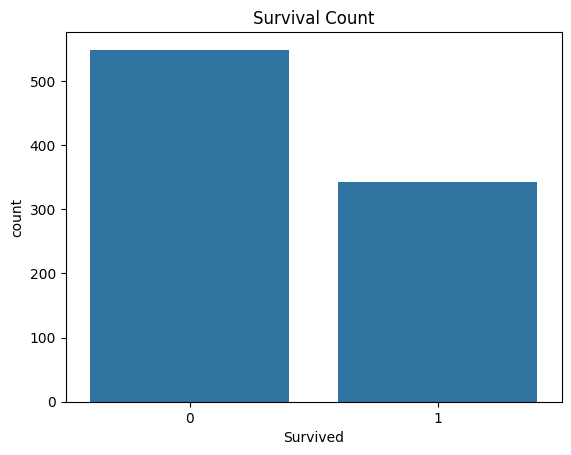

In [58]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()


Survival by Gender

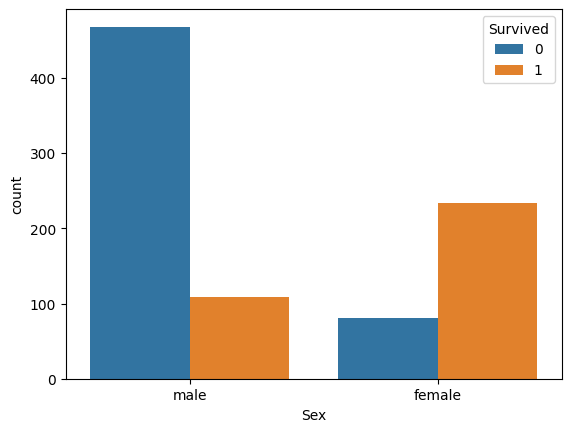

In [59]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()


Survival by Class

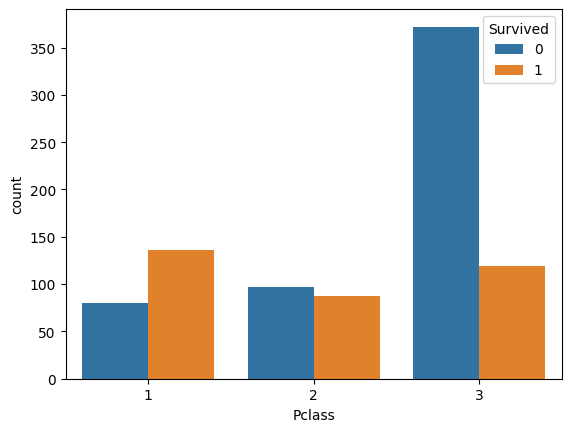

In [60]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()


Correlation Heatmap

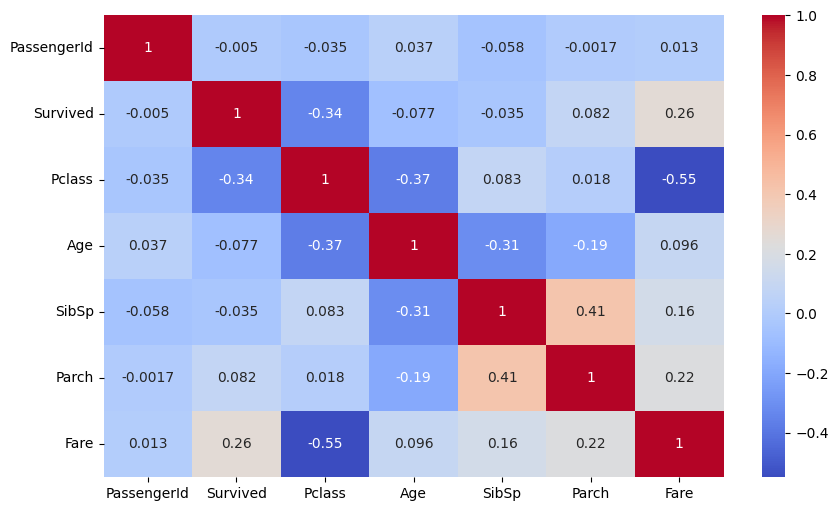

In [61]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


# STEP 5 — Advanced Feature Engineering
1️ Extract Title from Name

In [62]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme','Mrs')


2️ Family Size

In [63]:
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].fillna('Unknown')


3 Extract Deck from Cabin

In [64]:
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].fillna('Unknown')


4️ Fare Per Person

In [65]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1




In [66]:
df['FarePerPerson'] = df['Fare'] / df['FamilySize']


In [67]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['FarePerPerson'] = df['Fare'] / df['FamilySize'].replace(0,1)


In [68]:
print("Columns Available:\n", df.columns)
print("\nCheck if FamilySize exists:", 'FamilySize' in df.columns)


Columns Available:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'Deck',
       'FamilySize', 'FarePerPerson'],
      dtype='object')

Check if FamilySize exists: True


5 Age Imputation by Title Median

In [69]:
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))


6 Fill Remaining Missing Values

In [70]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)


# STEP 6 — Drop Unnecessary Columns

In [71]:
print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'Deck',
       'FamilySize', 'FarePerPerson'],
      dtype='object')


In [72]:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age',
 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [73]:
df.drop(['PassengerId','Name','Ticket','Cabin'], 
        axis=1, 
        inplace=True, 
        errors='ignore')


In [74]:
cols_to_drop = ['PassengerId','Name','Ticket','Cabin']

existing_cols = [col for col in cols_to_drop if col in df.columns]

df.drop(existing_cols, axis=1, inplace=True)


In [75]:
print("Current Columns:\n", df.columns.tolist())


Current Columns:
 ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'Deck', 'FamilySize', 'FarePerPerson']


# STEP 7 — Define Features & Target


In [76]:
X = df.drop('Survived', axis=1)
y = df['Survived']


# STEP 8 — Preprocessing Pipeline
Identify Numerical and Categorical Columns

In [77]:
num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include=['object']).columns


Create Transformers

In [78]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])


# STEP 9 — Train-Test Split

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


# STEP 10 — Model Training
 Logistic Regression

In [80]:
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

log_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'FarePerPerson'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Sex', 'Embarked', 'Title', 'Deck'], dtype='object'))])),
                ('classifier', LogisticRegression())])

Random Forest

In [81]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'FarePerPerson'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Sex', 'Embarked', 'Title', 'Deck'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

XGBoost

In [82]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(eval_metric='logloss'))
])

xgb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'FarePerPerson'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncod...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

# STEP 11 — Model Evaluation Function

In [83]:
def evaluate(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()


Logistic Regression
Accuracy: 0.8156424581005587
ROC-AUC: 0.8897039897039898

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.84       105
           1       0.77      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



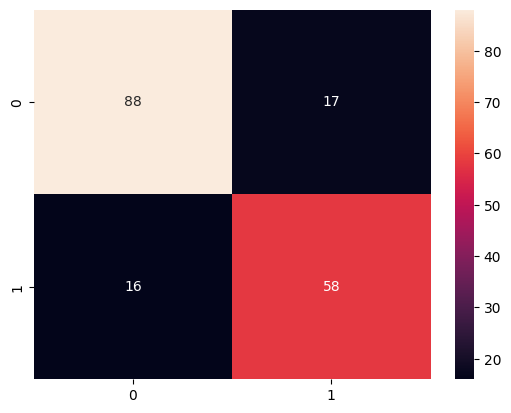

Random Forest
Accuracy: 0.8324022346368715
ROC-AUC: 0.9021879021879022

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



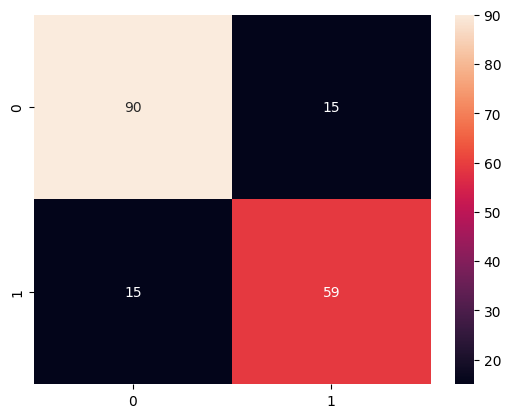

XGBoost
Accuracy: 0.8268156424581006
ROC-AUC: 0.8945945945945946

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.85       105
           1       0.79      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



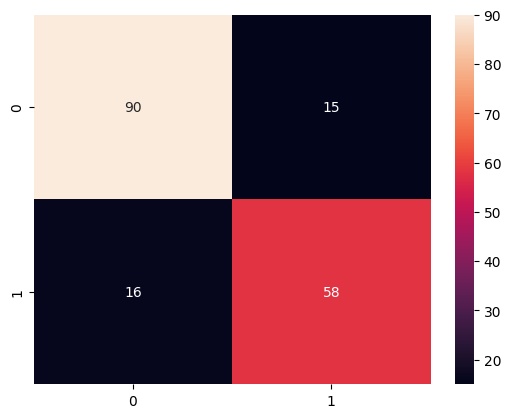

In [84]:
print("Logistic Regression")
evaluate(log_model)

print("Random Forest")
evaluate(rf_model)

print("XGBoost")
evaluate(xgb_model)


# STEP 12 — Hyperparameter Tuning (Random Forest)

In [85]:
param_grid = {
    'classifier__n_estimators': [100,200,300],
    'classifier__max_depth': [5,10,20]
}

grid = GridSearchCV(rf_model, param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_


Best Parameters: {'classifier__max_depth': 5, 'classifier__n_estimators': 200}


# STEP 13 — Ensemble Voting Classifier

Accuracy: 0.8324022346368715
ROC-AUC: 0.915057915057915

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86       105
           1       0.81      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



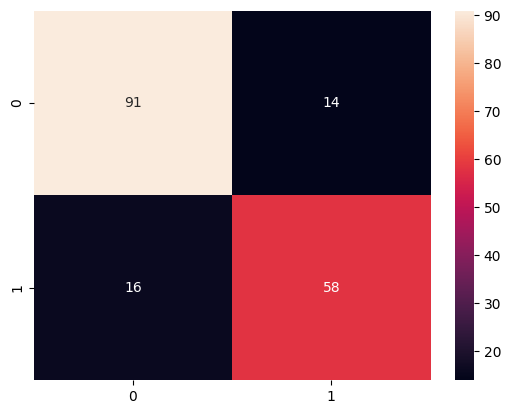

In [86]:
voting_model = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)
evaluate(voting_model)


# STEP 14 — Save Best Model

In [95]:
import joblib
joblib.dump(best_model, "titanic_best_model.pkl")


['titanic_best_model.pkl']

# STEP 15 — Final Results Comparison

In [96]:
models = {
    "Logistic": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Voting": voting_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))


Logistic Accuracy: 0.8156424581005587
Random Forest Accuracy: 0.7988826815642458
XGBoost Accuracy: 0.8268156424581006
Voting Accuracy: 0.8324022346368715


Handle Class Imbalance Using SMOTE

In [97]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote = SMOTE(random_state=42)

xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', xgb.XGBClassifier(eval_metric='logloss'))
])

xgb_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'FarePerPerson'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncod...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

# Bayesian Hyperparameter Tuning (OPTUNA)

In [98]:
!pip install optuna


In [99]:
import optuna

def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }
    
    model = xgb.XGBClassifier(**param, eval_metric='logloss')
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict_proba(X_test)[:,1]
    
    return roc_auc_score(y_test, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Parameters:", study.best_params)


[I 2026-02-11 05:12:19,638] A new study created in memory with name: no-name-7b012e7d-bf63-47a9-9628-7eee5f9e7789
[I 2026-02-11 05:12:19,753] Trial 0 finished with value: 0.9038610038610039 and parameters: {'n_estimators': 165, 'max_depth': 3, 'learning_rate': 0.297496580365986, 'subsample': 0.7437851081738788, 'colsample_bytree': 0.6819417881055512}. Best is trial 0 with value: 0.9038610038610039.
[I 2026-02-11 05:12:19,881] Trial 1 finished with value: 0.9102960102960103 and parameters: {'n_estimators': 142, 'max_depth': 8, 'learning_rate': 0.2862879598698444, 'subsample': 0.7486110343265808, 'colsample_bytree': 0.7834171565408805}. Best is trial 1 with value: 0.9102960102960103.
[I 2026-02-11 05:12:20,193] Trial 2 finished with value: 0.9056628056628058 and parameters: {'n_estimators': 460, 'max_depth': 7, 'learning_rate': 0.08755672400595402, 'subsample': 0.7010954964558711, 'colsample_bytree': 0.6003834992793725}. Best is trial 1 with value: 0.9102960102960103.
[I 2026-02-11 05:12

Best Parameters: {'n_estimators': 252, 'max_depth': 6, 'learning_rate': 0.043569270614648645, 'subsample': 0.951666532726934, 'colsample_bytree': 0.6597509694086093}


# Stacking Classifier (Meta Learning)

In [100]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf', RandomForestClassifier()),
    ('gb', GradientBoostingClassifier()),
    ('xgb', xgb.XGBClassifier(eval_metric='logloss'))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', stack_model)
])

stack_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'FarePerPerson'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncod...
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))],
                                    final_estimator=LogisticRegression()))])

# Probability Calibration

In [101]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    xgb.XGBClassifier(**study.best_params, eval_metric='logloss'),
    method='isotonic'
)

cal_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', calibrated_model)
])

cal_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'FarePerPerson'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncod...
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.043569270614648645,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=6,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=252,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...),
                                        method='isotonic'))])

# Threshold Optimization (Critical in Real World)

In [103]:
from sklearn.metrics import f1_score
import numpy as np

y_probs = cal_pipeline.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.01)
scores = []

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    scores.append(f1_score(y_test, preds))

best_threshold = thresholds[np.argmax(scores)]
print("Best Threshold:", best_threshold)


Best Threshold: 0.3699999999999999


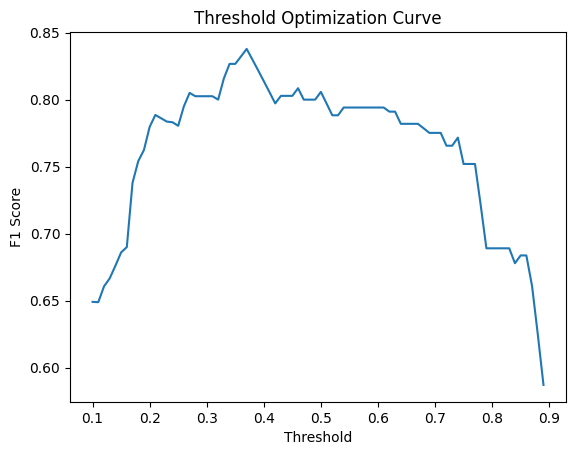

In [104]:
import matplotlib.pyplot as plt

plt.plot(thresholds, scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Optimization Curve")
plt.show()


# Feature Selection Using RFECV

In [105]:
from sklearn.feature_selection import RFECV

rf = RandomForestClassifier()

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', RFECV(rf, cv=5)),
    ('classifier', rf)
])

pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'FarePerPerson'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Sex', 'Embarked', 'Title', 'Deck'], dtype='object'))])),
                ('feature_selection',
                 RFECV(cv=5, estimator=RandomForestClassifier())),
                ('classifier', RandomForestClassifier())])

# Fairness & Bias Analysis (Very Powerful)

In [106]:
test_df = X_test.copy()
test_df['Actual'] = y_test.values
test_df['Predicted'] = cal_pipeline.predict(X_test)

gender_bias = test_df.groupby('Sex')['Predicted'].mean()
print(gender_bias)


Sex
female    0.811594
male      0.081818
Name: Predicted, dtype: float64


# Calibration Curve

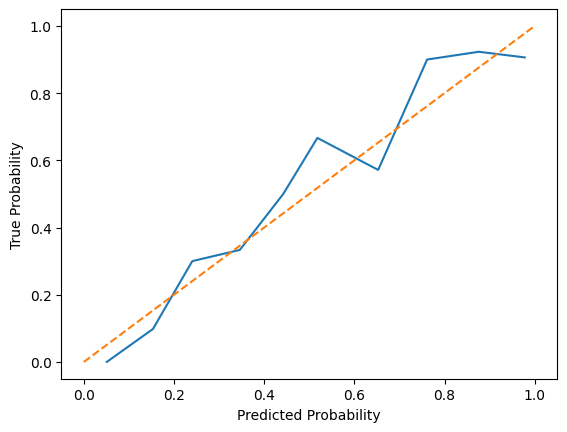

In [107]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.show()


# Error Analysis

In [108]:
errors = X_test.copy()
errors['Actual'] = y_test.values
errors['Predicted'] = cal_pipeline.predict(X_test)

misclassified = errors[errors['Actual'] != errors['Predicted']]
misclassified.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Deck,FamilySize,FarePerPerson,Actual,Predicted
137,1,male,37.0,1,0,53.1000,S,Mr,C,2,26.5500,0,1
621,1,male,42.0,1,0,52.5542,S,Mr,D,2,26.2771,1,0
447,1,male,34.0,0,0,26.5500,S,Mr,Unknown,1,26.5500,1,0
192,3,female,19.0,1,0,7.8542,S,Miss,Unknown,2,3.9271,1,0
673,2,male,31.0,0,0,13.0000,S,Mr,Unknown,1,13.0000,1,0


# Create Production Scoring Function

In [113]:
def predict_survival(input_data):

    # Convert to dataframe
    df_input = pd.DataFrame([input_data])
    
    # ----- Feature Engineering (MUST match training) -----

    # Title
    df_input['Title'] = df_input['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    
    rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
    df_input['Title'] = df_input['Title'].replace(rare_titles, 'Rare')
    df_input['Title'] = df_input['Title'].replace(['Mlle','Ms'], 'Miss')
    df_input['Title'] = df_input['Title'].replace('Mme','Mrs')

    # Family Size
    df_input['FamilySize'] = df_input['SibSp'] + df_input['Parch'] + 1

    # Deck
    df_input['Deck'] = df_input['Cabin'].str[0]
    df_input['Deck'] = df_input['Deck'].fillna('Unknown')

    # Fare Per Person
    df_input['FarePerPerson'] = df_input['Fare'] / df_input['FamilySize']

    # Drop unused columns
    df_input.drop(['PassengerId','Name','Ticket','Cabin'], axis=1, errors='ignore', inplace=True)

    # ----- Prediction -----
    prob = cal_pipeline.predict_proba(df_input)[0][1]
    prediction = 1 if prob >= best_threshold else 0

    return {
        "Survival Probability": float(prob),
        "Prediction": int(prediction)
    }


In [114]:
sample_passenger = {
    "PassengerId": 999,
    "Pclass": 1,
    "Name": "Smith, Mr. John",
    "Sex": "male",
    "Age": 35,
    "SibSp": 0,
    "Parch": 0,
    "Ticket": "PC 12345",
    "Fare": 80,
    "Cabin": "C85",
    "Embarked": "S"
}

predict_survival(sample_passenger)


{'Survival Probability': 0.44516395926475527, 'Prediction': 1}